In [4]:
from pathlib import Path
import json

import pandas as pd
import numpy as np


run_dir = Path(".").resolve() / "runs" 


names = [
    "exp_aggregation_2ae9865c86_Bikes_20260817_131836",
    "exp_aggregation_6ba3a8c889_Svhn_20260817_131836",
    "exp_aggregation_97e9f1e345_Cifar10_20260817_131836",
    "exp_aggregation_63536f9c1b_Energy_20260817_131836",
]


def parse_value(value):
    try:
        return int(value)
    except ValueError:
        return value


def parse_stem(path):
    stem = path.stem.removesuffix("_metrics")
    parts = stem.split("_")

    if len(parts) % 2 != 0:
        raise ValueError(f"Expected key_value pairs, got: {path.name}")

    return {
        parts[i]: parse_value(parts[i + 1])
        for i in range(0, len(parts), 2)
    }

dfs = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*_metrics.json"))

    _, exp_type, launch_id, task, t1, t2 = name.split("_")

    for path in metric_files:
        info = parse_stem(path)

        with path.open() as f:
            metrics = json.load(f)

        metrics = {
            k: np.asarray(v)
            for k, v in metrics.items()
        }

        shapes = {k: v.shape for k, v in metrics.items()}

        if len(set(shapes.values())) != 1:
            raise ValueError(
                f"Metric shapes differ in {path.name}: {shapes}"
            )

        shape = next(iter(shapes.values()))

        if len(shape) != 2:
            raise ValueError(
                f"Expected metrics shaped (epoch, seed), got {shape} "
                f"in {path.name}"
            )

        n_epochs, n_seeds = shape

        # Flatten in row-major order:
        # epoch 0 seed 0..N, epoch 1 seed 0..N, ...
        metrics_df = pd.DataFrame({
            k: v.reshape(-1)
            for k, v in metrics.items()
        })

        metrics_df["epoch"] = np.repeat(
            np.arange(n_epochs),
            n_seeds,
        )

        metrics_df["seed_id"] = np.tile(
            np.arange(n_seeds),
            n_epochs,
        )

        metrics_df["run_id"] = info.pop("run")
        metrics_df["task"] = task


        for key, value in info.items():
            metrics_df[key] = value

        # metrics_df["experiment"] = name

        dfs.append(metrics_df)


df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(
    ["run_id", "seed_id", "epoch"]
).reset_index(drop=True)

[PosixPath('/home/viktor/Documents/liquid/liquid_jax/runs/exp_aggregation_2ae9865c86_Bikes_20260817_131836/run_00001_predictors_32_delegators_32_pwidth_16_dwidth_16_mixing_sum_ambiguity_none_metrics.json'), PosixPath('/home/viktor/Documents/liquid/liquid_jax/runs/exp_aggregation_2ae9865c86_Bikes_20260817_131836/run_00002_predictors_32_delegators_32_pwidth_16_dwidth_16_mixing_product_ambiguity_none_metrics.json'), PosixPath('/home/viktor/Documents/liquid/liquid_jax/runs/exp_aggregation_2ae9865c86_Bikes_20260817_131836/run_00003_predictors_2_delegators_8_pwidth_4_dwidth_8_mixing_sum_ambiguity_none_metrics.json'), PosixPath('/home/viktor/Documents/liquid/liquid_jax/runs/exp_aggregation_2ae9865c86_Bikes_20260817_131836/run_00004_predictors_2_delegators_8_pwidth_4_dwidth_8_mixing_product_ambiguity_none_metrics.json'), PosixPath('/home/viktor/Documents/liquid/liquid_jax/runs/exp_aggregation_2ae9865c86_Bikes_20260817_131836/run_00005_predictors_2_delegators_2_pwidth_8_dwidth_16_mixing_sum_amb

In [6]:
df.columns

Index(['validation_loss', 'validation_load_balancing_loss',
       'validation_performance_loss', 'validation_r2_metric', 'loss',
       'load_balancing_loss', 'performance_loss', 'r2_metric', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_accuracy_metric',
       'accuracy_metric'],
      dtype='str')

In [7]:
df.memory_usage().sum() / 1_000_000_000

np.float64(0.734475132)

In [33]:
df["task"].value_counts()

task
Bikes      1500000
Energy     1000000
Cifar10      42500
Svhn         29500
Name: count, dtype: int64

In [8]:
cifar: pd.DataFrame = df[df["task"] == "Cifar10"].copy()

In [44]:
exp_vars = ["predictors", "delegators", "pwidth", "dwidth"]
var_oi = "mixing"
loss_col = "validation_performance_loss"

def get_metric_col(task):
    if task in {"Cifar10", "Svhn"}:
        return "validation_accuracy_metric"
    elif task in {"Bikes", "Energy"}:
        return "validation_r2_metric" 
    else:
        raise ValueError(f"Unknown task {task}")

In [10]:
cifar.columns

Index(['validation_loss', 'validation_load_balancing_loss',
       'validation_performance_loss', 'validation_r2_metric', 'loss',
       'load_balancing_loss', 'performance_loss', 'r2_metric', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_accuracy_metric',
       'accuracy_metric'],
      dtype='str')

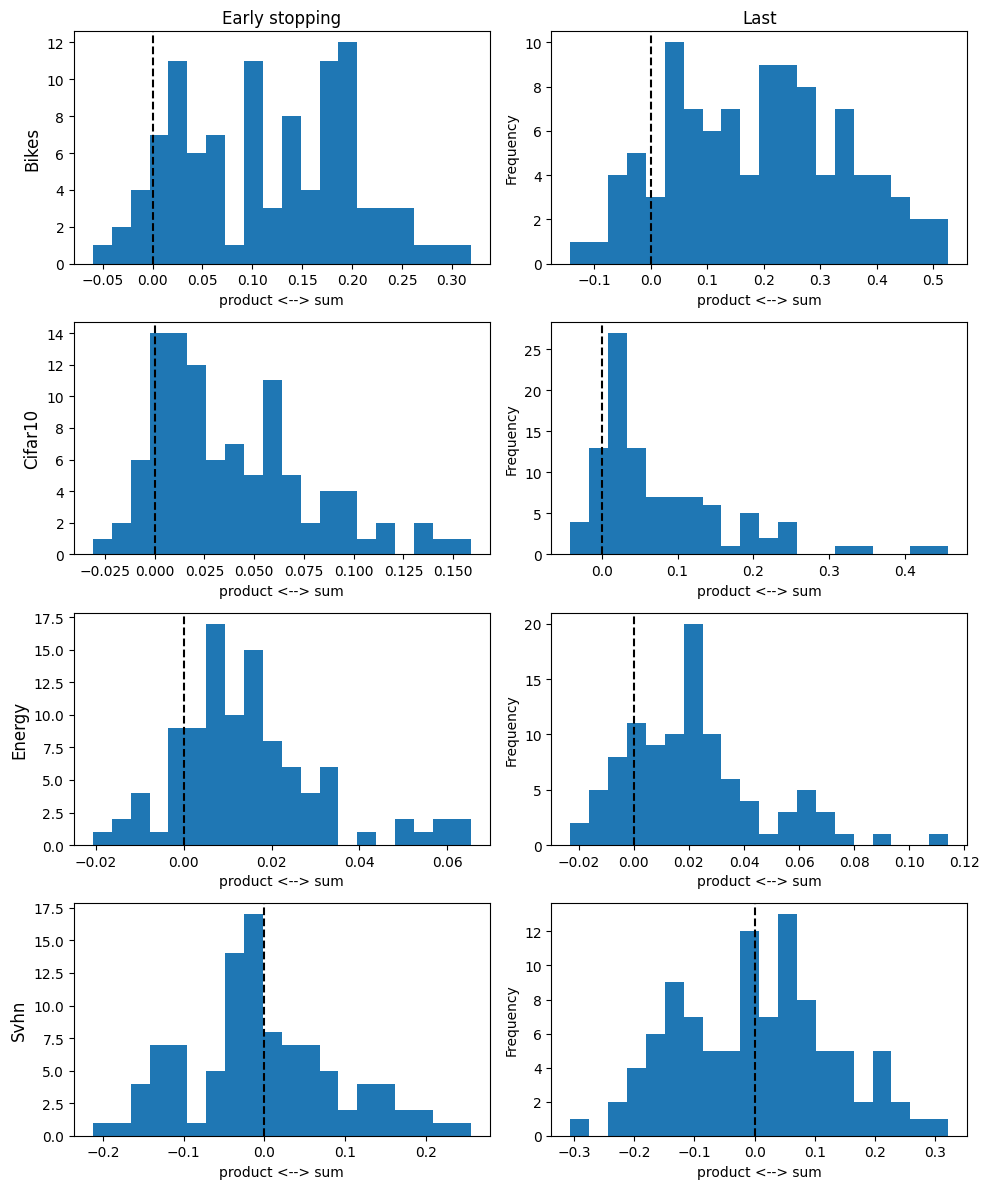

In [46]:
from typing import Literal

from matplotlib import pyplot as plt


def pair_up(single_task: pd.DataFrame, n_in_pair: int = 2):

    if n_in_pair < 1:
        raise ValueError("n_in_pair must be >= 1")

    if single_task.duplicated("run_id").any():
        raise ValueError("Run id duplicates")

    run_ids = (
        single_task["run_id"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    n_complete = (len(run_ids) // n_in_pair) * n_in_pair
    run_ids = run_ids.iloc[:n_complete]

    pairs = pd.DataFrame({
        "run_id": run_ids,
        "pair_id": np.arange(n_complete) // n_in_pair,
    })

    df = single_task.merge(pairs, on="run_id", how="inner")

    inconsistent = (
        df.groupby("pair_id")[exp_vars]
        .nunique(dropna=False)
        .gt(1)
        .any(axis=1)
    )

    if inconsistent.any():
        bad = inconsistent.index[inconsistent].tolist()
        raise ValueError(f"Pairs contain inconsistent exp_vars: {bad}")

    return df.reset_index(drop=True)

def select_last(single_task: pd.DataFrame):
    return (
        single_task
        .sort_values(["run_id", "epoch"])
        .groupby("run_id")
        .tail(1)
    )

def select_early_stopping(single_task: pd.DataFrame):
    idx = single_task.groupby("run_id")[loss_col].idxmin()
    return single_task.loc[idx].copy()

def pivot_to_metrics(paired: pd.DataFrame, *cols: str):

    cols = list(cols)

    if len(cols) == 0:
        cols = [loss_col]

    if len(cols) == 1:
        cols = cols[0]

    return pd.pivot(paired, index="pair_id", columns="mixing", values=cols)
    

def plot_relative_diff(pivot: pd.DataFrame, ax, out: Literal["loss", "metric"] = "loss"):

    if out == "loss":
        agg_product = pivot["product"] 
        agg_sum = pivot["sum"]

        relative_diff = (agg_product - agg_sum) / (
            (agg_product.abs() + agg_sum.abs()) / 2
        )

        relative_diff.plot.hist(bins=20, ax=ax)
        ax.set_xlabel("product <--> sum")

    elif out == "metric":
        agg_product = pivot["product"] 
        agg_sum = pivot["sum"]

        diff = (agg_product - agg_sum)

        diff.plot.hist(bins=20, ax=ax)
        ax.set_xlabel("sum <--> product")


fig, axs = plt.subplots(4, 2, figsize=(10, 12))

axs[0, 0].set_title("Early stopping")
axs[0, 1].set_title("Last")

for i_task, (task, task_df) in enumerate(df.groupby("task")):

    axl, axr = axs[i_task, :]

    task_df.pipe(select_early_stopping).pipe(pair_up).pipe(pivot_to_metrics).pipe(lambda df: plot_relative_diff(df, axl))
    task_df.pipe(select_last).pipe(pair_up).pipe(pivot_to_metrics).pipe(lambda df: plot_relative_diff(df, axr))

    axl.axvline(0, color="black", linestyle="dashed")
    axr.axvline(0, color="black", linestyle="dashed")

    axl.set_ylabel(task, fontsize=12)

fig.tight_layout()


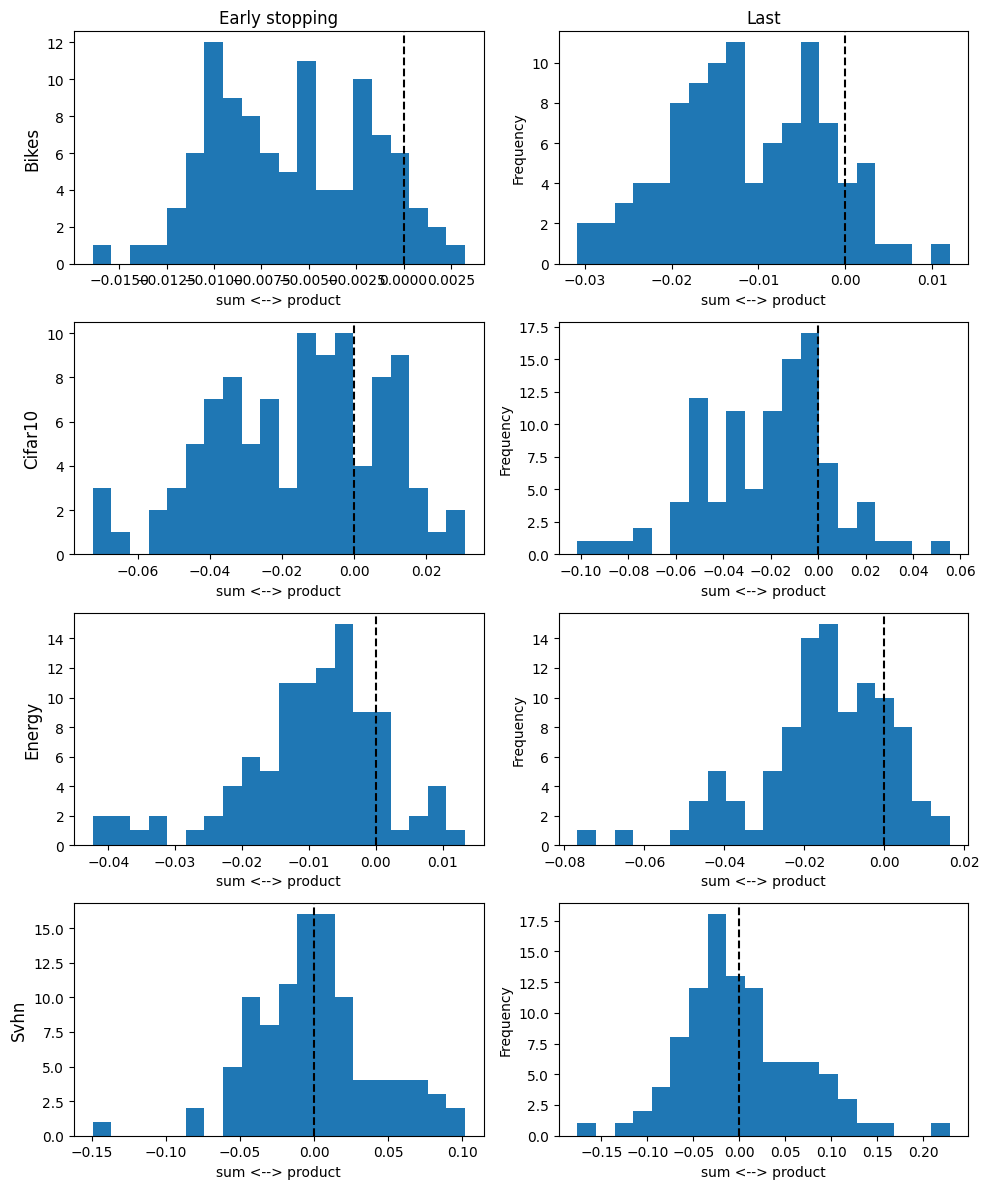

In [47]:
fig, axs = plt.subplots(4, 2, figsize=(10, 12))

axs[0, 0].set_title("Early stopping")
axs[0, 1].set_title("Last")

for i_task, (task, task_df) in enumerate(df.groupby("task")):

    axl, axr = axs[i_task, :]

    task_df.pipe(select_early_stopping).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axl, "metric"))
    task_df.pipe(select_last).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axr, "metric"))

    axl.axvline(0, color="black", linestyle="dashed")
    axr.axvline(0, color="black", linestyle="dashed")

    axl.set_ylabel(task, fontsize=12)

fig.tight_layout()

In [42]:
df

,validation_loss,validation_load_balancing_loss,validation_performance_loss,validation_r2_metric,loss,load_balancing_loss,performance_loss,r2_metric,epoch,seed_id,run_id,task,predictors,delegators,pwidth,dwidth,mixing,ambiguity,validation_accuracy_metric,accuracy_metric
0,0.674423,0.001921,0.672502,0.329991,0.823737,0.000351,0.823386,0.174827,0,0,1,Bikes,32,32,16,16,sum,none,NaN,NaN
1,1.763123,0.041665,1.721458,NaN,2.086112,0.018919,2.067193,NaN,0,0,1,Svhn,32,32,16,16,sum,none,0.414062,0.265897
2,1.838127,0.016610,1.821517,NaN,1.944130,0.016631,1.927500,NaN,0,0,1,Cifar10,32,32,16,16,sum,none,0.355469,0.308021
3,0.811836,0.009005,0.802831,0.191691,0.876485,0.003273,0.873212,0.124164,0,0,1,Energy,32,32,16,16,sum,none,NaN,NaN
4,0.528830,0.017218,0.511612,0.490284,0.571668,0.009827,0.561841,0.436705,1,0,1,Bikes,32,32,16,16,sum,none,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4199995,0.688377,0.003362,0.685015,0.310310,0.508849,0.004183,0.504666,0.492684,1997,4,200,Energy,32,2,16,16,product,none,NaN,NaN
4199996,0.091817,0.017004,0.074813,0.925464,0.026185,0.017619,0.008566,0.991263,1998,4,200,Bikes,32,2,16,16,product,none,NaN,NaN
4199997,0.681481,0.003329,0.678152,0.317221,0.512128,0.004164,0.507964,0.487974,1998,4,200,Energy,32,2,16,16,product,none,NaN,NaN
4199998,0.091696,0.017006,0.074690,0.925587,0.026042,0.017577,0.008465,0.991454,1999,4,200,Bikes,32,2,16,16,product,none,NaN,NaN


(np.float64(0.1626953125),
 np.float64(0.5365234375),
 np.float64(0.1626953125),
 np.float64(0.5365234375))

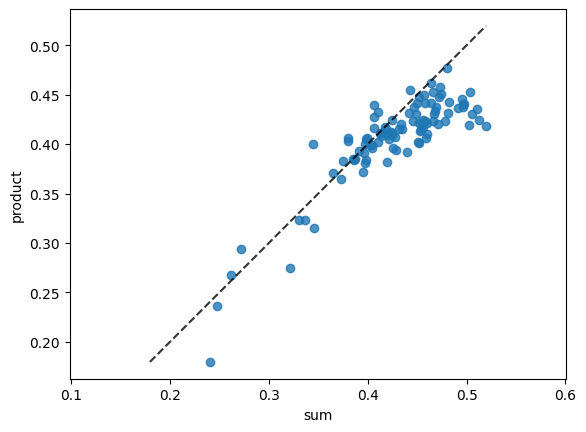

In [21]:
import matplotlib.pyplot as plt

plt.scatter(
    paired_last_cifar["sum"],
    paired_last_cifar["product"],
    alpha=0.8,
)

lo = min(
    paired_last_cifar["sum"].min(),
    paired_last_cifar["product"].min(),
)
hi = max(
    paired_last_cifar["sum"].max(),
    paired_last_cifar["product"].max(),
)

plt.plot([lo, hi], [lo, hi], "--", alpha=0.8, color="black")

plt.xlabel("sum")
plt.ylabel("product")
plt.axis("equal")

In [22]:
nan_mask = df[loss_col].isnull()

df_nan = df[nan_mask]
df_nan.groupby(["task", "mixing"]).size()

Series([], dtype: int64)

In [102]:
df.columns

Index(['validation_loss', 'validation_accuracy_metric',
       'validation_load_balancing_loss', 'validation_performance_loss', 'loss',
       'accuracy_metric', 'load_balancing_loss', 'performance_loss', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_r2_metric', 'r2_metric'],
      dtype='str')

In [104]:
# Focus on product mixing first
prod = df[df["mixing"] == "product"].copy()
prod["loss_is_nan"] = prod[loss_col].isna()

print(
    prod["loss_is_nan"]
    .value_counts(normalize=True)
    .rename("fraction")
)

(
    df.assign(loss_is_nan=df[loss_col].isna())
      .groupby(["task", "mixing"])
      ["loss_is_nan"]
      .agg(["sum", "count", "mean"])
      .sort_values("mean", ascending=False)
)

loss_is_nan
False    0.733653
True     0.266347
Name: fraction, dtype: float64


,,sum,count,mean
task,mixing,,,
Cifar10,product,9194,21000,0.437810
Energy,product,159951,500000,0.319902
Bikes,product,170361,750000,0.227148
Svhn,product,2883,14500,0.198828
Cifar10,sum,0,21500,0.000000
Bikes,sum,0,750000,0.000000
Energy,sum,0,500000,0.000000
Svhn,sum,0,15000,0.000000


In [105]:
(
    prod.groupby("task")["loss_is_nan"]
        .agg(["sum", "count", "mean"])
        .sort_values("mean", ascending=False)
)

,sum,count,mean
task,,,
Cifar10,9194,21000,0.437810
Energy,159951,500000,0.319902
Bikes,170361,750000,0.227148
Svhn,2883,14500,0.198828


In [106]:
config_cols = [
    "task",
    "predictors",
    "delegators",
    "pwidth",
    "dwidth",
    "ambiguity",
]

for col in config_cols:
    print(f"\n--- {col} ---")
    display(
        prod.groupby(col, dropna=False)["loss_is_nan"]
            .agg(["sum", "count", "mean"])
            .query("sum > 0")
            .sort_values("mean", ascending=False)
            .head(30)
    )


--- task ---


,sum,count,mean
task,,,
Cifar10,9194,21000,0.437810
Energy,159951,500000,0.319902
Bikes,170361,750000,0.227148
Svhn,2883,14500,0.198828



--- predictors ---


,sum,count,mean
predictors,,,
4,103339,277500,0.372393
8,71673,226500,0.316437
2,79613,363000,0.219320
32,77368,357500,0.216414
16,10396,61000,0.170426



--- delegators ---


...

,sum,count,mean
pwidth,,,
4,179873,431000,0.417339
8,107301,453000,0.236868
16,55215,401500,0.137522



--- dwidth ---


,sum,count,mean
dwidth,,,
8,156029,493500,0.316168
4,76187,309500,0.246162
16,110173,482500,0.228338



--- ambiguity ---


,sum,count,mean
ambiguity,,,
none,342389,1285500,0.266347


In [107]:
(
    prod.groupby(["task", "pwidth"])["loss_is_nan"]
    .agg(n_nan="sum", n="count", nan_rate="mean")
    .reset_index()
    .pivot(index="task", columns="pwidth", values="nan_rate")
)

pwidth,4,8,16
task,,,
Bikes,0.372708,0.202864,0.092645
Cifar10,0.505692,0.417733,0.396286
Energy,0.482112,0.289869,0.185959
Svhn,0.322222,0.179455,0.099111


In [109]:
# Expected max epochs by task
max_epochs = {
    "Bikes": 2000,
    "Energy": 2000,
    "Cifar10": 100,
    "Svhn": 100,
}

prod = df[df["mixing"] == "product"].copy()
prod["loss_is_nan"] = prod[loss_col].isna()

# First NaN epoch per run
first_nan = (
    prod.loc[prod["loss_is_nan"]]
        .groupby(["run_id", "task", "pwidth"], dropna=False)["epoch"]
        .min()
        .rename("first_nan_epoch")
        .reset_index()
)

first_nan["max_epochs"] = first_nan["task"].map(max_epochs)

# 0 = immediate failure, 1 = failure at end of training
first_nan["first_nan_frac"] = (
    first_nan["first_nan_epoch"] / first_nan["max_epochs"]
)

In [110]:
first_nan.groupby("pwidth")["first_nan_frac"].describe(
    percentiles=[.1, .25, .5, .75, .9]
)

,count,mean,std,min,10%,25%,50%,75%,90%,max
pwidth,,,,,,,,,,
4,53.0,0.225028,0.099971,0.065,0.1167,0.14000,0.22300,0.262000,0.3640,0.5800
8,47.0,0.271394,0.130877,0.030,0.1380,0.17775,0.26050,0.354000,0.4252,0.7330
16,44.0,0.378693,0.191337,0.020,0.1630,0.22400,0.36425,0.479125,0.6055,0.8915


In [111]:
(
    first_nan.groupby(["task", "pwidth"])["first_nan_frac"]
    .agg(
        n_failed="size",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
)

n_failed      mean  median       std     min     max
task    pwidth                                                      
Bikes   4             20  0.177850  0.1560  0.080725  0.0650  0.3275
        8             18  0.284194  0.2640  0.151588  0.1085  0.7330
        16            16  0.495406  0.4735  0.205112  0.2070  0.8915
Cifar10 4             12  0.228333  0.2150  0.092720  0.1000  0.3800
        8             12  0.235000  0.2050  0.139251  0.0300  0.5200
        16            11  0.210909  0.2000  0.107560  0.0200  0.4000
Energy  4             13  0.239192  0.2260  0.081293  0.1150  0.3845
        8             12  0.315000  0.3245  0.083092  0.1735  0.4545
        16            13  0.418154  0.4215  0.127285  0.2290  0.6055
Svhn    4              8  0.315000  0.3000  0.125357  0.1700  0.5800
        8              5  0.208000  0.2300  0.107564  0.0900  0.3600
        16             4  0.245000  0.2600  0.067577  0.1500  0.3100

In [114]:
import numpy as np
import pandas as pd

prod = df[df["mixing"] == "product"].copy()
prod["loss_is_nan"] = prod[loss_col].isna()

prod["task_type"] = prod["task"].map({
    "Bikes": "regression",
    "Energy": "regression",
    "Cifar10": "image",
    "Svhn": "image",
})

# Variables we want to investigate
features = [
    "pwidth",
    "dwidth",
    "predictors",
    "delegators",
    "ambiguity",
    "seed_id",
]

# ------------------------------------------------------------
# One row per RUN.
# A run "failed" if loss became NaN at any point.
# ------------------------------------------------------------
run_df = (
    prod.groupby(
        ["task_type", "task", "run_id"] + features,
        dropna=False
    )
    .agg(
        failed=("loss_is_nan", "any"),
        first_nan_epoch=(
            "epoch",
            lambda x: (
                x[prod.loc[x.index, "loss_is_nan"]].min()
                if prod.loc[x.index, "loss_is_nan"].any()
                else np.nan
            )
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Rank variables by how much failure rate changes across values.
#
# effect_range = max failure rate - min failure rate
#
# Large value => variable strongly associated with NaNs
# Near zero   => variable doesn't explain much
# ------------------------------------------------------------
results = []

for task_type, g in run_df.groupby("task_type"):

    for feature in features:

        rates = (
            g.groupby(feature, dropna=False)["failed"]
            .agg(
                n_runs="size",
                n_failed="sum",
                failure_rate="mean",
            )
            .reset_index()
        )

        # Ignore extremely tiny groups if present
        rates_valid = rates[rates["n_runs"] >= 5]

        if len(rates_valid) < 2:
            continue

        effect_range = (
            rates_valid["failure_rate"].max()
            - rates_valid["failure_rate"].min()
        )

        results.append({
            "task_type": task_type,
            "feature": feature,
            "effect_range": effect_range,
            "min_failure_rate": rates_valid["failure_rate"].min(),
            "max_failure_rate": rates_valid["failure_rate"].max(),
        })

        print("\n" + "=" * 70)
        print(f"{task_type.upper()} — {feature}")
        print("=" * 70)

        print(
            rates.sort_values(feature)
            .to_string(index=False)
        )

# Overall ranking
ranking = (
    pd.DataFrame(results)
    .sort_values(
        ["task_type", "effect_range"],
        ascending=[True, False]
    )
)

print("\n\n" + "#" * 70)
print("VARIABLES RANKED BY ASSOCIATION WITH NaN FAILURE")
print("#" * 70)

display(
    ranking.style.format({
        "effect_range": "{:.3f}",
        "min_failure_rate": "{:.3f}",
        "max_failure_rate": "{:.3f}",
    })
)


IMAGE — pwidth
 pwidth  n_runs  n_failed  failure_rate
      4     110        78      0.709091
      8     130        67      0.515385
     16     115        50      0.434783

IMAGE — dwidth
 dwidth  n_runs  n_failed  failure_rate
      4      95        48      0.505263
      8     135        89      0.659259
     16     125        58      0.464000

IMAGE — predictors
 predictors  n_runs  n_failed  failure_rate
          2     130        39      0.300000
          4      75        52      0.693333
          8      65        40      0.615385
         16      10         8      0.800000
         32      75        56      0.746667

IMAGE — delegators
 delegators  n_runs  n_failed  failure_rate
          0      55         0      0.000000
          1      10         0      0.000000
          2      55        22      0.400000
          4      65        46      0.707692
          8      35        23      0.657143
         16      75        56      0.746667
         32      60        48      0

,task_type,feature,effect_range,min_failure_rate,max_failure_rate
3,image,delegators,0.800,0.000,0.800
2,image,predictors,0.500,0.300,0.800
0,image,pwidth,0.274,0.435,0.709
1,image,dwidth,0.195,0.464,0.659
4,image,seed_id,0.183,0.437,0.620
8,regression,delegators,0.673,0.000,0.673
7,regression,predictors,0.341,0.267,0.607
5,regression,pwidth,0.321,0.308,0.629
6,regression,dwidth,0.201,0.353,0.554
9,regression,seed_id,0.128,0.376,0.504


In [115]:
prod = df[df["mixing"] == "product"].copy()
prod["failed"] = prod[loss_col].isna()

prod["task_type"] = prod["task"].map({
    "Bikes": "regression",
    "Energy": "regression",
    "Cifar10": "image",
    "Svhn": "image",
})

run_df = (
    prod.groupby(
        ["task_type", "task", "run_id",
         "pwidth", "dwidth", "predictors", "delegators"],
        dropna=False
    )
    .agg(failed=("failed", "any"))
    .reset_index()
)

for task_type, g in run_df.groupby("task_type"):
    print(f"\n{'='*80}")
    print(task_type.upper())
    print(f"{'='*80}")

    table = (
        g.groupby(["delegators", "pwidth"])
         .agg(
             n_runs=("failed", "size"),
             n_failed=("failed", "sum"),
             failure_rate=("failed", "mean"),
         )
         .reset_index()
    )

    print(
        table.pivot(
            index="delegators",
            columns="pwidth",
            values="failure_rate"
        ).round(3)
    )


IMAGE
pwidth       4     8      16
delegators                  
0           0.0  0.00  0.000
1           NaN   NaN  0.000
2           1.0  0.60  0.500
4           1.0  1.00  0.800
8           NaN  0.75  0.667
16          1.0  1.00  1.000
32          1.0  1.00  1.000

REGRESSION
pwidth       4    8      16
delegators                 
0           0.0  0.0  0.000
1           0.0  0.0  0.000
2           1.0  1.0  0.857
4           1.0  1.0  1.000
8           NaN  1.0  1.000
16          1.0  1.0  0.800
32          1.0  1.0  1.000
